<a href="https://colab.research.google.com/github/pachterlab/cellmender/blob/main/intro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
# try:
#     from cellmender import denoise_count_matrix
# except ImportError:
#     print("cellmender not found, installing...")
#     !pip install -U -q cellmender[analysis]

In [17]:
import os
import anndata as ad
import scanpy as sc
from cellmender import denoise_count_matrix
import cellmender.utils as cm_utils

cellmender_dir = os.path.dirname(os.path.abspath(""))

# import importlib
# import cellmender.celltype_ambient
# importlib.reload(cellmender.celltype_ambient)
# from cellmender.celltype_ambient import denoise_count_matrix

# import importlib
# import cellmender.utils as cm_utils
# importlib.reload(cm_utils)
# from cellmender.utils import plot_matrix_scatterplot

# Intro

In [18]:
data_dir = os.path.join(cellmender_dir, "notebooks", "data", "pbmc1k")
os.makedirs(data_dir, exist_ok=True)

out_dir = os.path.join(cellmender_dir, "notebooks", "output", "pbmc1k")
os.makedirs(out_dir, exist_ok=True)

adata_raw_path = os.path.join(data_dir, "sc5p_v2_hs_PBMC_1k_f_raw_feature_bc_matrix.h5")
if not os.path.exists(adata_raw_path):
    !curl -L -o "{adata_raw_path}" "https://cf.10xgenomics.com/samples/cell-vdj/4.0.0/sc5p_v2_hs_PBMC_1k/sc5p_v2_hs_PBMC_1k_f_raw_feature_bc_matrix.h5"

adata_raw = sc.read_10x_h5(adata_raw_path)
expected_cells = 1_000
model_pkl = "Immune_All_High.pkl"

adata_cellmender_path = os.path.join(out_dir, "adata_cellmender.h5ad")

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 4127k  100 4127k    0     0  34.0M      0 --:--:-- --:--:-- --:--:-- 33.8M


## Knee plot - use this output to estimate cs_empty_threshold

UMI cutoff for expected cells (1000): 0.00


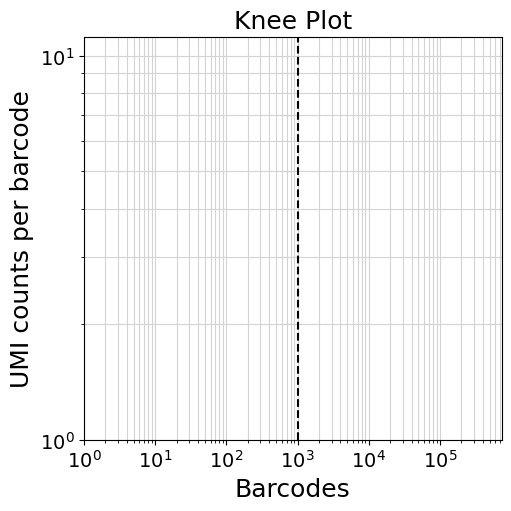

In [14]:
cm_utils.knee_plot(adata_raw, expected_cells=expected_cells, out_path=os.path.join(out_dir, "knee_plot.png"))

## Determine cell types - here, we use celltypist, but you can use any method you like

In [ ]:
adata = cm_utils.determine_cell_types(adata_raw, model_pkl=model_pkl, filter_empty=True, expected_cells=expected_cells, verbose=2)

## Run cellmender

In [ ]:
%time
adata_cellmender = denoise_count_matrix(adata, adata_out=adata_cellmender_path, max_iter=40, beta=0.3, eps=1e-9, empty_droplet_method="threshold", expected_cells=expected_cells, cell_ambient_fraction=0.01, verbose=2, log_file=os.path.join(out_dir, "cellmender.log"))
# adata_cellmender = ad.read_h5ad(adata_cellmender_path)

## Filter empty droplets

In [ ]:
adata_cellmender = adata_cellmender[~adata_cellmender.obs["is_empty"]].copy()

## Basic analysis

In [ ]:
print(f"Raw:\n{adata_raw}\n\n")
print(f"cellmender:\n{adata_cellmender}\n\n")
print("Fraction of cells retained after cellmender:", adata_cellmender.n_obs / adata_raw.n_obs)

In [ ]:
upset_data_dict = {
    "Raw": set(adata_raw.obs_names),
    "cellmender": set(adata_cellmender.obs_names),
}

_ = cm_utils.make_upset_plot(upset_data_dict, title="Cells Retained After CellMender", out_path=os.path.join(out_dir, "cells_retained_upset.png"))

In [ ]:
cm_utils.plot_matrix_scatterplot(adata_raw, adata_cellmender, scale="log", x_axis="raw", y_axis="cellmender", out_path=os.path.join(out_dir, "raw_vs_cellmender_expression_scatterplot.png"), show=True)